# FDSI benchmark: 3. Application

`AdaptDecomp.from_calibration` builds the online decomposition from a calibration, and
`process_data` runs it batch by batch over the rest of the recording, from the end of the
calibration window. Each recording is decomposed with no adaptation (`fixed`, the calibrated
model applied unchanged) and with each search's winner, and every unit is scored against the
ground truth: its RoA over the whole recording and per phase of the contraction, and its SIL.

Every recording changes the wrist angle during the contraction, so the motor units' action
potentials change shape: a fixed decomposition loses them, an adaptive one should keep them.

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "benchmarks" / "fdsi").is_dir()
)
sys.path.insert(0, str(REPO_ROOT))  # so that benchmarks.fdsi imports from any working directory

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

from adapt_decomp import AdaptDecomp, CBSSConfig, CBSSResult
from adapt_decomp.adaptation import AdaptConfig
from adapt_decomp.spikes import get_sil, rate_of_agreement_paired
from adapt_decomp.utils.plots import plot_sources
from benchmarks.fdsi import fdsi, pipeline

cfg = pipeline.load_config()
DATA_ROOT, FS = pipeline.REPO_ROOT / cfg["data_root"], cfg["grid"]["fs"]
CAL_END = pipeline.cal_end(cfg)

## One recording

Subject 2's 20 s triangular ramp at 20 dB, a contraction no search saw, decomposed with no
adaptation and with the `sv_mean` search's winner (read from `results/`, so no search is
needed). Its calibration comes from [1. Calibration](1_calibrate.ipynb), computed here if
missing.

In [3]:
rec = fdsi.Recording("sub-02", "triangular-ramp20s", 20)
pipeline.calibrate_one(cfg, rec)  # skipped if done
calibration = CBSSResult.load(pipeline.calibration_path(cfg, rec))
emg = fdsi.load_raw_emg(DATA_ROOT, rec)
gt = fdsi.load_gt_matched(DATA_ROOT, rec, calibration.gt_matched_indices, len(emg))

configs = {
    "No adaptation": AdaptConfig.from_yaml(pipeline.REPO_ROOT / cfg["fixed_config"]),
    "sv_loss, mean": AdaptConfig.from_yaml(cfg["results"] / "configs" / "sv_mean.yaml"),
}
spikes, sources, roa, sil = {}, {}, {}, {}
for name, adapt_config in configs.items():
    adapt_config.source_fifo_from_calib = True  # the EMG starts where calibration ends
    adapter = AdaptDecomp.from_calibration(
        calibration=calibration,
        cbss_config=CBSSConfig(**cfg["calibration"]["cbss_config"]),
        adapt_config=adapt_config,
    )
    outputs = adapter.process_data(emg[CAL_END:])

    # The whole recording: CBSS's own output over the calibration window, then the adaptation's
    spikes[name] = np.concatenate([calibration.spikes, outputs.spikes.numpy()])
    sources[name] = np.concatenate([calibration.sources, outputs.sources.numpy()])
    sil[name] = get_sil(
        torch.from_numpy(sources[name]),
        torch.from_numpy(spikes[name]),
        adapt_config.spike_min_dist,
        peak_power=adapt_config.spike_det_exp,
    ).numpy()
    roa[name], _, _ = rate_of_agreement_paired(
        gt, spikes[name], fs=FS, tol_spike_ms=cfg["grid"]["tol_spike_ms"]
    )
    print(f"{name}: mean RoA {roa[name].mean():.1%}, mean SIL {sil[name].mean():.2f}")

No adaptation: mean RoA 41.3%, mean SIL 0.94
sv_loss, mean: mean RoA 97.2%, mean SIL 0.94


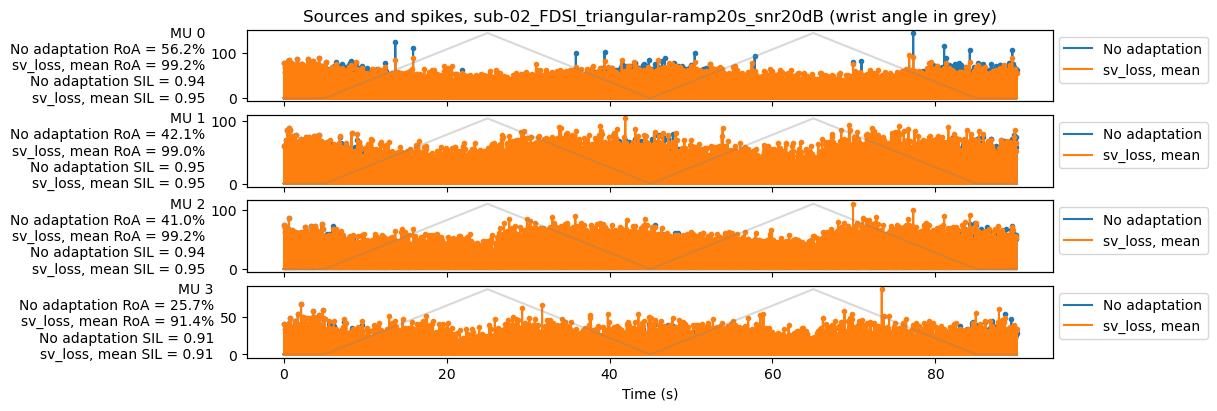

In [4]:
ts = np.arange(len(emg)) / FS
angle = fdsi.load_angle_profile(DATA_ROOT, rec.sub, rec.cond)
axs = plot_sources(sources, ts, spikes=spikes, roa=roa, sil=sil, square_sources=True)
for ax in np.atleast_1d(axs):
    ax_angle = ax.twinx()
    ax_angle.plot(ts, angle, color="grey", alpha=0.3, zorder=0)
    ax_angle.set_yticks([])
np.atleast_1d(axs)[0].set_title(f"Sources and spikes, {rec.stub} (wrist angle in grey)")
plt.show()

## Every recording

The previous code is looped in `benchmarks/fdsi/pipeline.py` to run across all contractions. A task whose output already exists is skipped, so set `RUN`
to `True` to compute only what is missing. Outside a notebook, the same stage runs with
`python -m benchmarks.fdsi apply --workers 8` (add `--quick` for the small check of
`config.yaml`'s `quick` section), or on a PBS cluster as array jobs with
`bash benchmarks/fdsi/pbs/submit.sh`.

Every config on every recording is 600 tasks of about 4 min each: about 5 h on 8 cores. The
stage needs the searches' winners: from [2. Search](2_search.ipynb)'s outputs if you ran them,
or else those published in `results/`. Then `collect` gathers every score into `results/`, which
[4. Results](4_results.ipynb) reads.

The published outputs (`adapt-decomp-data get fdsi_benchmark-outputs-v1.1.0`: every applied
config's spikes and sources and the searches' trials) can be scored without recomputing
anything: `collect` scores every saved result that has no scores yet.

In [5]:
RUN = False
if RUN:
    pipeline.run(cfg, "apply", n_workers=os.cpu_count())
    pipeline.run(cfg, "collect")

Next: [4. Results](4_results.ipynb) over every recording.